In [1]:
from math import e
from PBR import PBR
from Reaction import Reaction
from KineticModel import KineticModel
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle

In [2]:
pd.options.display.max_seq_items = 2000

In [3]:
# loading data for plotting
# Remenber: the fit was also performed on reconciled data
with open('reconciled_data.pkl', 'rb') as f:
    data = pickle.load(f)
kinetic_data = data.loc[data['CINÉTICA'] == 1.0].reset_index()
kinetic_data['m_cat_kg'] = kinetic_data['m_cat_g']/1000

In [4]:
kinetic_data.head()

,index,t_h,CINÉTICA,PLOT,DESATIVAÇÃO,BM,VALIDATION,P_abs_Pa,T_R_K,F_H2_e_mol_s,...,OL_P_13,OL_P_14,OL_P_15,OL_P_16,OL_P_17,OL_P_18,alpha,K_C2,K_C3,m_cat_kg
0,43,5.5,1.0,1.0,1.0,1.0,NaN,2247156.184,506.15,0.000122,...,0.150592,0.096941,0.074273,0.043962,0.017821,0.0,0.446048,1.804884,-0.342300,0.00512
1,44,6.0,1.0,1.0,1.0,1.0,NaN,2240261.427,506.15,0.000122,...,0.150592,0.096941,0.074273,0.043962,0.017821,0.0,0.397480,1.670047,-0.425235,0.00512
2,45,6.5,1.0,1.0,1.0,1.0,NaN,2233366.670,506.15,0.000122,...,0.150592,0.096941,0.074273,0.043962,0.017821,0.0,0.438943,19.565460,-0.502566,0.00512
3,46,7.0,1.0,1.0,1.0,1.0,NaN,2233366.670,506.15,0.000122,...,0.150592,0.096941,0.074273,0.043962,0.017821,0.0,0.387038,1.587622,-0.300304,0.00512
4,52,13.0,1.0,1.0,0.0,1.0,NaN,2191998.128,495.15,0.000098,...,0.150592,0.096941,0.074273,0.043962,0.017821,0.0,0.720966,7.351071,3.432052,0.00512


In [5]:
F0 = kinetic_data['F_CO_e_mol_s'].mean() + kinetic_data['F_H2_e_mol_s'].mean()
F0

np.float64(0.00013850197875136432)

In [6]:
H2_CO = kinetic_data['$H_2/CO$'].mean()
x_CO = 1 / ( 1 + H2_CO )
x_H2 = 1 - x_CO

In [7]:
# create reactor object
T0 = (220, 'C')
x0 = {
                  'carbon monoxide': x_CO,
                  'hydrogen' : x_H2,
              }
reactor = PBR(T0 = T0, 
              P0 = (20, 'bar'), 
              x0 = x0, 
              F0 = (F0, 'mol/s'),
              isothermal = True, 
              ergun = True,
              WT = (5.12, 'g'), 
              W_steps = 50,
              U = (300, 'W/m2/K'),
              D = (7, 'mm'),
              Dp = (0.1725, 'mm'),
              pellet_density = (2530, 'kg/m3'),
              Ta = T0,
              liquid_phase = False,
              units = 'SI',
              solver_method = 'BDF',
              rtol = 1e-5, atol = 1e-7,
              calculate_equilibrium = False,
              equilibrium_obj_fun_tolerance = 1e-12,
              log = True,
             )

In [8]:
from models_FTS.Yates            import Yates
from models_FTS.PowerLaw         import PowerLaw
from models_FTS.Botes            import Botes
from models_FTS.vanSteen         import vanSteen
from models_FTS.Ojeda            import Ojeda
from models_FTS.Mousavi          import Mousavi
from models_FTS.MousaviPLaw      import MousaviPLaw
from models_FTS.Wang             import Wang
from models_FTS.WangSimple       import WangSimple
from models_FTS.Elementary       import Elementary

In [9]:
Yates       =      Yates()
PowerLaw    =      PowerLaw()
Botes       =      Botes()
vanSteen    =      vanSteen()
Ojeda       =      Ojeda()
Mousavi     =      Mousavi()
MousaviPLaw =      MousaviPLaw()
Wang        =      Wang()
WangSimple  =      WangSimple()
Elementary  =      Elementary()

In [10]:
reactor.add_model(Yates)

x0 not provided for methane, assuming value is 0.
x0 not provided for water, assuming value is 0.
x0 not provided for ethane, assuming value is 0.
x0 not provided for propane, assuming value is 0.
x0 not provided for butane, assuming value is 0.
x0 not provided for pentane, assuming value is 0.
x0 not provided for hexane, assuming value is 0.
x0 not provided for heptane, assuming value is 0.
x0 not provided for octane, assuming value is 0.
x0 not provided for nonane, assuming value is 0.
x0 not provided for decane, assuming value is 0.
x0 not provided for undecane, assuming value is 0.
x0 not provided for dodecane, assuming value is 0.
x0 not provided for tridecane, assuming value is 0.
x0 not provided for tetradecane, assuming value is 0.
x0 not provided for pentadecane, assuming value is 0.
x0 not provided for hexadecane, assuming value is 0.
x0 not provided for heptadecane, assuming value is 0.
x0 not provided for octadecane, assuming value is 0.
x0 not provided for nonadecane, assu

In [11]:
model = 'Yates'

In [12]:
param_dict_T0 = {
              'T0'             : (np.linspace(180, 260, num = 20), 'C'),
              # 'P0'             : ([1e5], 'Pa'),
              # 'F0'             : ([0.0003286777777777], 'mol/s'),
              # 'x0'             : [{'methane': 1 - x_H2O - ( 1 - x_H2O ) / ( 1 + CH4_CO2 ), 
              #                      'water': x_H2O,
              #                      'carbon dioxide': ( 1 - x_H2O ) / ( 1 + CH4_CO2 ),
              #                      'carbon monoxide': 0.0,
              #                      'hydrogen': 0.0} for x_H2O in np.linspace(0.1, 0.9, num = 25, endpoint = True)],
              # 'isothermal'     : [False],
              # 'ergun'          : [False],
              # 'U'              : ([121], 'W/m2/K'),
              # 'D'              : ([1], 'in'),
              # 'Dp'             : ([4], 'mm'),
              # 'Ta'             : ([800], 'C'),
            }

In [13]:
reactor.W_steps = 2
dfs = reactor.parametric_study(param_dict_T0,
                               'parametric_results_FTS/parametric_study',
                               conversions = ['carbon monoxide', 'hydrogen'],
                              )
parametric_T0 = dfs[model]

Solution 20 of 20
{'T0': np.float64(260.0)}


In [14]:
kinetic_data.columns

Index(['index', 't_h', 'CINÉTICA', 'PLOT', 'DESATIVAÇÃO', 'BM', 'VALIDATION',
       'P_abs_Pa', 'T_R_K', 'F_H2_e_mol_s', 'F_CO_e_mol_s', 'F_H2O_e_mol_s',
       'F_CO2_e_mol_s', 'F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s',
       'F_CO2_s_mol_s', 'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s',
       'F_H2O_s_mol_s', 'X_CO', 'X_H2', 'm_cat_g', 'CODE', 'm_SEP_acum (g)',
       'frac_cera', 'w_C7', 'w_C8', 'w_C9', 'w_C10', 'w_C11', 'w_C12', 'w_C13',
       'w_C14', 'w_C15', 'w_C16', 'w_C17', 'w_C18', 'w_C19', 'w_C20', 'w_C21',
       'w_C22', 'w_C23', 'w_C24', 'w_C25', 'w_C26', 'w_C27', 'w_C28', 'w_C29',
       'w_C30', 'w_C31', 'w_C32', 'w_C33', 'w_C34', 'w_C35', 'w_C36',
       'LIQ_SAMPLE', 'w_C7_olef', 'w_C8_olef', 'w_C9_olef', 'w_C10_olef',
       'w_C11_olef', 'w_C12_olef', 'w_C13_olef', 'w_C14_olef', 'w_C15_olef',
       'w_C16_olef', 'w_C17_olef', 'w_C18_olef', 'T (ºC)', 'F_Olef_C2_e',
       'F_Olef_C3_e', 'F_Olef_C7_e', 'F_Olef_C8_e', 'F_Olef_C9_e',
       'F_Olef_C1

In [15]:
plots_leg = {
             'carbon monoxide'      : 'CO',
             'X_CO'                 : 'CO',
             'F_CO_s_mol_s'         : 'CO',
             'hydrogen'             : r'$\mathrm{H_2}$',
             'X_H2'                 : r'$\mathrm{H_2}$',
             'F_H2_s_mol_s'         : r'$\mathrm{H_2}$',
            }

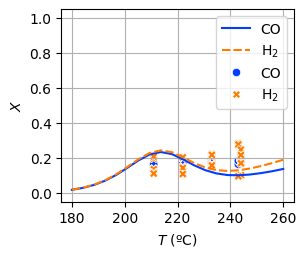

In [16]:
kinetic_data_filtered = kinetic_data[['T_R_C', 'X_CO', 'X_H2']]
kinetic_data_filtered = kinetic_data_filtered.melt(id_vars = 'T_R_C')

fig, ax = plt.subplots(figsize=(3,2.5))
sns.lineplot(x = 'T0 (C)', y = 'X',
             data = parametric_T0.loc[(parametric_T0['X'].notna()) & (parametric_T0['W'] == parametric_T0['W'].max())],
             hue = 'variable',
             style = 'variable',
             palette = 'bright'
            )
sns.scatterplot(x = 'T_R_C', y = 'value',
             data = kinetic_data_filtered,
             hue = 'variable',
             style = 'variable',
             palette = 'bright'
            )
handles, labels = ax.get_legend_handles_labels()
labels = [plots_leg[label] for label in labels if label in plots_leg]
plt.legend(handles, labels)
plt.ylim(-0.05, 1.05)
plt.xlabel(r'$T$ (ºC)')
plt.ylabel(r'$X$')
plt.grid('both')

In [17]:
kinetic_data_filtered

,T_R_C,variable,value
0,233.0,X_CO,0.184845
1,233.0,X_CO,0.190503
2,233.0,X_CO,0.188424
3,233.0,X_CO,0.188226
4,222.0,X_CO,0.156093
...,...,...,...
133,233.0,X_H2,0.151696
134,233.0,X_H2,0.157660
135,211.0,X_H2,0.116437
136,211.0,X_H2,0.111565


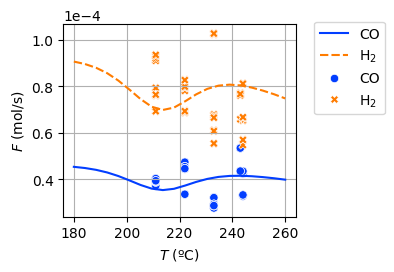

In [18]:
kinetic_data_filtered = kinetic_data[['T_R_C', 'F_CO_s_mol_s', 'F_H2_s_mol_s']]
kinetic_data_filtered = kinetic_data_filtered.melt(id_vars = 'T_R_C')

fig, ax = plt.subplots(figsize=(3,2.5))
sns.lineplot(x = 'T0 (C)', y = 'value',
             data = parametric_T0.loc[(parametric_T0['X'].notna()) & (parametric_T0['W'] == parametric_T0['W'].max())],
             hue = 'variable',
             style = 'variable',
             palette = 'bright'
            )
sns.scatterplot(x = 'T_R_C', y = 'value',
             data = kinetic_data_filtered,
             hue = 'variable',
             style = 'variable',
             palette = 'bright'
            )
ax.ticklabel_format(style='sci', scilimits=(0,0), axis = 'y')
handles, labels = ax.get_legend_handles_labels()
labels = [plots_leg[label] for label in labels if label in plots_leg]
plt.legend(handles, labels, bbox_to_anchor=(1.05, 1.05))
plt.xlabel(r'$T$ (ºC)')
plt.ylabel(r'$F$ (mol/s)')
plt.grid('both')

In [19]:
from pympler import asizeof

asizeof.asizeof(reactor)

5836848